In [164]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 1

sns.set_theme(style="whitegrid")

---

## Split the Data into Training and Testing Sets

### Step 1: Read the `lending_data.csv` data from the `Resources` folder into a Pandas DataFrame.

In [165]:
# Read the CSV file from the data folder intoa pandas DataFrame.
DATA_PATH = Path("../data/lending_data.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

loans_df = pd.read_csv(DATA_PATH)
loans_df.head()

,loan_size,interest_rate,borrower_income,debt_to_income,num_of_accounts,derogatory_marks,total_debt,loan_status
0,10700.0,7.672,52800,0.431818,5,1,22800,0
1,8400.0,6.692,43600,0.311927,3,0,13600,0
2,9000.0,6.963,46100,0.349241,3,0,16100,0
3,10700.0,7.664,52700,0.430740,5,1,22700,0
4,10800.0,7.698,53000,0.433962,5,1,23000,0


### Step 2: Create the labels set (`y`)  from the “loan_status” column, and then create the features (`X`) DataFrame from the remaining columns.

In [166]:
# Separate the data into labels and features
# Separate the y variable, the labels
y = loans_df["loan_status"]

# Separate the X variable, the features
X = loans_df.drop(columns="loan_status")


In [167]:
# Review the y variable Series

y.head()

0    0
1    0
2    0
3    0
4    0
Name: loan_status, dtype: int64

In [168]:
# Review the X variable DataFrame

X.head()

,loan_size,interest_rate,borrower_income,debt_to_income,num_of_accounts,derogatory_marks,total_debt
0,10700.0,7.672,52800,0.431818,5,1,22800
1,8400.0,6.692,43600,0.311927,3,0,13600
2,9000.0,6.963,46100,0.349241,3,0,16100
3,10700.0,7.664,52700,0.430740,5,1,22700
4,10800.0,7.698,53000,0.433962,5,1,23000


### Examine the Target-Class Distribution

Because high-risk loans are much less common than healthy loans, overall accuracy may overstate model performance. Class-specific precision, recall, and balanced accuracy are therefore important.

In [169]:
class_labels = {
    0: "Healthy Loan",
    1: "High-Risk Loan",
}

class_summary = (
    y.map(class_labels)
    .value_counts()
    .rename_axis("loan_type")
    .reset_index(name="count")
)

class_summary["percentage"] = (
    class_summary["count"]
    .div(len(y))
    .mul(100)
    .round(2)
)

class_summary

,loan_type,count,percentage
0,Healthy Loan,75036,96.78
1,High-Risk Loan,2500,3.22


### Step 3: Split the data into training and testing datasets by using `train_test_split`.

In [170]:
# Split the data using train_test_split
# Assign a random_state of 1 to the function


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

In [171]:
#Class distribution section 

class_labels = {0: "Healthy Loan", 1: "High-Risk Loan"}

class_summary = (
    y.map(class_labels)
    .value_counts()
    .rename_axis("loan_type")
    .reset_index(name="count")
)

class_summary["percentage"] = (
    class_summary["count"]
    .div(len(y))
    .mul(100)
    .round(2)
)

class_summary

,loan_type,count,percentage
0,Healthy Loan,75036,96.78
1,High-Risk Loan,2500,3.22


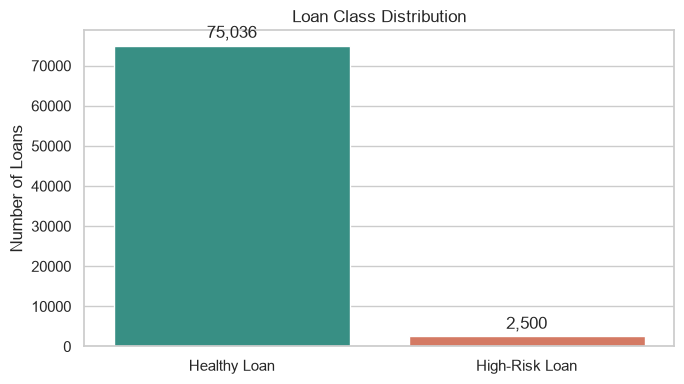

In [172]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=class_summary,
    x="loan_type",
    y="count",
    hue="loan_type",
    palette={
        "Healthy Loan": "#2a9d8f",
        "High-Risk Loan": "#e76f51",
    },
    legend=False,
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3)

ax.set(
    title="Loan Class Distribution",
    xlabel="",
    ylabel="Number of Loans",
)

plt.tight_layout()
plt.show()

---

## Create a Logistic Regression Model with the Original Data

###  Step 1: Fit a logistic regression model by using the training data (`X_train` and `y_train`).

In [173]:
# Instantiate the Logistic Regression model
# Assign a random_state parameter of 1 to the model
# Fit the model using training data

logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                solver="lbfgs",
                random_state=RANDOM_STATE,
                max_iter=1000,
            ),
        ),
    ]
)

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['loan_size','interest_rate','borrower_income',...,'num_of_accounts', 'derogatory_marks','total_debt']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


### Step 2: Save the predictions on the testing data labels by using the testing feature data (`X_test`) and the fitted model.

In [174]:
# Generate class predictions and high-risk probabilities
predictions = logistic_model.predict(X_test)
prediction_probabilities = logistic_model.predict_proba(X_test)[:, 1]

prediction_results = pd.DataFrame(
    {
        "Prediction": predictions,
        "Actual": y_test,
        "High-Risk Probability": prediction_probabilities,
    }
).reset_index(drop=True)

prediction_results.head(10)


,Prediction,Actual,High-Risk Probability
0,0,0,1.734626e-06
1,1,1,7.089604e-01
2,0,0,1.092039e-02
3,0,0,3.365008e-04
4,0,0,1.107563e-08
5,0,0,9.625643e-08
6,0,0,1.775952e-07
7,0,0,1.386880e-06
8,0,0,9.701270e-05
9,0,0,9.153470e-08


In [175]:
print(
    f"Balanced accuracy: "
    f"{balanced_accuracy_score(y_test, predictions):.3f}"
)
print(
    f"ROC-AUC: "
    f"{roc_auc_score(y_test, prediction_probabilities):.3f}"
)
print(
    f"Average precision: "
    f"{average_precision_score(y_test, prediction_probabilities):.3f}"
)

Balanced accuracy: 0.986
ROC-AUC: 0.996
Average precision: 0.862


### Step 3: Evaluate the model’s performance by doing the following:

* Generate a confusion matrix.

* Print the classification report.

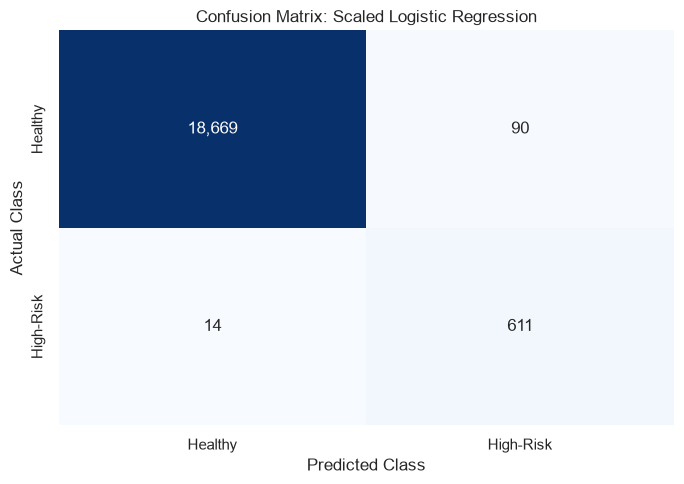

In [176]:
# Generate a confusion matrix for the model
confusion_matrix_df = pd.DataFrame(
    confusion_matrix(y_test, predictions),
    index=["Healthy", "High-Risk"],
    columns=["Healthy", "High-Risk"],
)

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    confusion_matrix_df,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    ax=ax,
)

ax.set_title("Confusion Matrix: Scaled Logistic Regression")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [177]:
# Print the classification report for the model

target_names = ["(0) Healthy Loan", "(1) High-Risk Loan"]
print(classification_report(y_test, predictions, target_names=target_names ))

                    precision    recall  f1-score   support

  (0) Healthy Loan       1.00      1.00      1.00     18759
(1) High-Risk Loan       0.87      0.98      0.92       625

          accuracy                           0.99     19384
         macro avg       0.94      0.99      0.96     19384
      weighted avg       1.00      0.99      0.99     19384



### Step 4: Answer the following question.

**Question:** How well does the logistic regression model predict both the `0` (healthy loan) and `1` (high-risk loan) labels?

**Answer:** 
## Model Performance Interpretation

The scaled logistic regression model performs strongly for both healthy and high-risk loans. It correctly identified 611 of the 625 high-risk loans, producing a recall of 0.98. This means the model detected approximately 98% of the loans that were actually high-risk.

The model’s high-risk precision is 0.87, meaning approximately 87% of the loans classified as high-risk were truly high-risk. The confusion matrix shows 14 false negatives—high-risk loans incorrectly classified as healthy—and 90 false positives—healthy loans incorrectly flagged as high-risk.

Because high-risk loans represent only a small portion of the dataset, overall accuracy alone could be misleading. The balanced accuracy of 0.986 confirms that the model performs well across both classes. The ROC-AUC score of 0.996 indicates excellent separation between healthy and high-risk loans, while the average precision score of 0.862 demonstrates strong performance when identifying the minority high-risk class.

Compared with the original unscaled model, scaling reduced the number of missed high-risk loans from 32 to 14 while keeping high-risk precision at approximately 0.87. This tradeoff is valuable in credit-risk screening because failing to identify a high-risk loan may be more costly than sending a healthy loan for additional review.

---